# Subfase IX: Calibración probabilística y contraste estadístico

## Propósito
Evaluar la calidad probabilística y contrastar estadísticamente los modelos clásicos y cuánticos entrenados para h=5.

## Entradas y salidas
- Entradas: artefactos y manifiestos en `models/classical/` y `models/quantum/`.
- Salidas: CSV y gráficos en `results/fase4_comparativa/` para calibración, prueba estadística, tablas de contingencia y comparación final.
- Alcance: análisis posterior al entrenamiento; no reemplaza los artefactos de modelado.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import proportion_confint

from bvg_core.config import (
    CLASSICAL_DIR,
    COMPANIES,
    DATA_MASTER_PATH as DATASET_PATH,
    EMPRESA_COL,
    FASE4_RESULTS,
    FECHA_COL_2,
    FEATURE_EXCLUDE,
    GLOBAL_SEED,
    QUANTUM_DIR,
    TARGET_COL,
    TEST_SIZE,
)
from bvg_core.quantum import build_qkernel
from bvg_core.splits import temporal_split_company
from bvg_core.utils import load_manifest, safe_company

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## Bloque 1: Calibración probabilística
Se calculan métricas de calibración y curvas confiabilidad-probabilidad para los modelos clásico y cuántico.

## Nota sobre Platt scaling (SVC lineal, C=0.1)

El SVC lineal con `C=0.1` usa Platt scaling para mapear los scores de decisión a probabilidades mediante una sigmoide. Un `C` pequeño regulariza fuerte y tiende a evitar scores extremadamente grandes, pero cuando los scores son muy extremos (muy negativos o muy positivos) la sigmoide satura y las probabilidades se acercan a 0 o 1. Esta saturación explica por qué, aun con un modelo lineal, los extremos del score pueden generar probabilidades poco sensibles a variaciones locales, afectando la calibración.

In [2]:
np.random.seed(GLOBAL_SEED)

OUT_CSV = FASE4_RESULTS / 'BVG_subfase8b_calibracion.csv'
OUT_PNG = FASE4_RESULTS / 'BVG_calibracion_plot.png'

N_BINS = 5

MODEL_FAMILIES = ['classical', 'quantum']

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [3]:
def compute_ece_manual(y_true: np.ndarray, proba: np.ndarray, n_bins: int = N_BINS) -> dict:
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(proba, bins, right=True) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    acc = []
    conf = []
    counts = []
    total = len(proba)
    ece = 0.0

    for b in range(n_bins):
        mask = bin_ids == b
        count = int(np.sum(mask))
        counts.append(count)
        if count == 0:
            acc.append(np.nan)
            conf.append(np.nan)
            continue
        acc_b = float(np.mean(y_true[mask]))
        conf_b = float(np.mean(proba[mask]))
        acc.append(acc_b)
        conf.append(conf_b)
        ece += (count / total) * abs(acc_b - conf_b)

    return {
        'ece': float(ece),
        'bin_edges': bins,
        'bin_acc': np.array(acc),
        'bin_conf': np.array(conf),
        'bin_counts': np.array(counts),
    }

def load_classical_model(path: Path):
    if not path.exists():
        raise FileNotFoundError(f'Modelo clásico no encontrado: {path}')
    return joblib.load(path)

def load_quantum_artifacts(prefix: str) -> dict:
    scaler_path = QUANTUM_DIR / f'{prefix}_scaler.joblib'
    pca_path = QUANTUM_DIR / f'{prefix}_pca.joblib'
    svc_path = QUANTUM_DIR / f'{prefix}_svc.joblib'
    cfg_path = QUANTUM_DIR / f'{prefix}_kernel_config.json'

    for p in [scaler_path, pca_path, svc_path, cfg_path]:
        if not p.exists():
            raise FileNotFoundError(f'Artifacto cuántico no encontrado: {p}')

    scaler = joblib.load(scaler_path)
    pca = joblib.load(pca_path)
    svc = joblib.load(svc_path)
    cfg = json.loads(cfg_path.read_text(encoding='utf-8'))

    return {'scaler': scaler, 'pca': pca, 'svc': svc, 'config': cfg}

def build_quantum_kernel(cfg: dict) -> FidelityQuantumKernel:
    feature_map = zz_feature_map(
        feature_dimension=int(cfg['feature_dimension']),
        reps=int(cfg['reps']),
        entanglement=cfg['entanglement'],
    )
    fidelity = ComputeUncompute(sampler=StatevectorSampler(seed=GLOBAL_SEED))
    return FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

def predict_quantum_proba(bundle: dict, X_train: pd.DataFrame, X_test: pd.DataFrame) -> np.ndarray:
    scaler = bundle['scaler']
    pca = bundle['pca']
    svc = bundle['svc']
    qkernel = build_quantum_kernel(bundle['config'])

    X_train_q = pca.transform(scaler.transform(X_train))
    X_test_q = pca.transform(scaler.transform(X_test))

    K_test = qkernel.evaluate(x_vec=X_test_q, y_vec=X_train_q)
    proba = svc.predict_proba(K_test)[:, 1]
    return proba

In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Dataset no encontrado: {DATASET_PATH}')

df = pd.read_csv(DATASET_PATH)

required = {FECHA_COL_2, EMPRESA_COL, TARGET_COL}
missing = sorted(required.difference(df.columns))
if missing:
    raise ValueError(f'Columnas faltantes: {missing}')

feature_cols = [c for c in df.columns if c not in FEATURE_EXCLUDE]
if not feature_cols:
    raise ValueError('No se pudieron inferir feature_cols.')

df = df.assign(**{FECHA_COL_2: pd.to_datetime(df[FECHA_COL_2], errors='coerce')})
df = df.dropna(subset=feature_cols + [TARGET_COL, FECHA_COL_2, EMPRESA_COL]).copy()
if df.empty:
    raise ValueError('Dataset vacío tras limpieza de NaN.')

df = df.sort_values([EMPRESA_COL, FECHA_COL_2], kind='stable').reset_index(drop=True)
df.head()

,fecha,empresa,close_last,close_vwap,volume_shares_day,turnover_value_day,n_trades_day,ret_lag_1,ret_lag_2,ret_lag_3,mom_3,mom_5,mom_10,vol_5,vol_10,regime_vol_ratio,ma_5,ma_10,ma_gap,price_vs_ma10,rsi_14,turnover_log1p,volume_log1p,avg_trade_size_log1p,amihud_5,days_since_trade,ret_fwd_h1,ret_fwd_h5,ret_fwd_h20,target_up_h1,target_up_h5,target_up_h20
0,2019-02-13,BANCO GUAYAQUIL S.A.,0.97,0.97,35000.0,33950.0,1.0,0.040822,-0.040822,0.000000,3.469447e-17,4.082199e-02,0.030459,0.034154,0.024103,1.416994,0.984,0.975,0.009,0.025641,62.452022,10.432674,10.463132,10.463132,0.000016,1.0,0.030459,0.030459,-0.010363,1.0,1.0,0.0
1,2019-02-19,BANCO GUAYAQUIL S.A.,1.00,1.00,2046.0,2046.0,6.0,-0.030459,0.040822,-0.040822,-3.045921e-02,1.036279e-02,0.010363,0.038424,0.026100,1.472155,0.986,0.976,0.010,-0.006148,52.665650,7.624131,7.624131,5.834811,0.000016,6.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0
2,2019-02-20,BANCO GUAYAQUIL S.A.,1.00,1.00,1500.0,1500.0,1.0,0.030459,-0.030459,0.040822,4.082199e-02,1.144917e-16,0.030459,0.036015,0.027627,1.303608,0.986,0.979,0.007,0.021450,59.078190,7.313887,7.313887,7.313887,0.000019,1.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0
3,2019-02-21,BANCO GUAYAQUIL S.A.,1.00,1.00,591494.0,591494.0,14.0,0.000000,0.030459,-0.030459,7.979728e-17,1.144917e-16,0.030459,0.036015,0.027627,1.303608,0.986,0.982,0.004,0.018330,59.078190,13.290409,13.290409,10.651373,0.000019,1.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0
4,2019-02-26,BANCO GUAYAQUIL S.A.,1.00,1.00,2771.0,2771.0,1.0,0.000000,0.000000,0.030459,3.045921e-02,4.082199e-02,0.030459,0.028234,0.027627,1.021964,0.994,0.985,0.009,0.015228,57.100950,7.927324,7.927324,7.927324,0.000003,5.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0


In [5]:
results = {}
metrics_rows = []

for company in COMPANIES:
    _, _, X_train, y_train, X_test, y_test = temporal_split_company(
        df,
        company,
        test_size=TEST_SIZE,
        company_col=EMPRESA_COL,
        date_col=FECHA_COL_2,
        target_col=TARGET_COL,
        feature_cols=feature_cols,
    )
    y_test_np = y_test.to_numpy(dtype=int)
   
    for model_family in MODEL_FAMILIES:
        prefix = f"{safe_company(company)}_h5"
        if model_family == 'classical':
            model_path = CLASSICAL_DIR / f'{prefix}_pipeline.joblib'
            pipeline = load_classical_model(model_path)
            proba = pipeline.predict_proba(X_test)[:, 1]
        else:
            bundle = load_quantum_artifacts(prefix)
            proba = predict_quantum_proba(bundle, X_train, X_test)

        prob_true, prob_pred = calibration_curve(y_test_np, proba, n_bins=N_BINS)
        ece_payload = compute_ece_manual(y_test_np, proba, n_bins=N_BINS)

        mean_proba = float(np.mean(proba))
        std_proba = float(np.std(proba))
        pct_above_60 = float(np.mean(proba > 0.60) * 100.0)
        pct_below_40 = float(np.mean(proba < 0.40) * 100.0)

        key = (company, model_family)
        results[key] = {
            'y_test': y_test_np,
            'proba': proba,
            'prob_true': prob_true,
            'prob_pred': prob_pred,
            'ece': ece_payload['ece'],
            'bin_counts': ece_payload['bin_counts'],
        }

        metrics_rows.append({
            'company': company,
            'model_family': model_family,
            'ece': ece_payload['ece'],
            'mean_proba': mean_proba,
            'std_proba': std_proba,
            'pct_proba_above_60': pct_above_60,
            'pct_proba_below_40': pct_below_40,
        })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[[
    'company', 'model_family', 'ece', 'mean_proba', 'std_proba',
    'pct_proba_above_60', 'pct_proba_below_40'
]]

metrics_df.to_csv(OUT_CSV, index=False)
metrics_df

,company,model_family,ece,mean_proba,std_proba,pct_proba_above_60,pct_proba_below_40
0,BANCO GUAYAQUIL S.A.,classical,0.039081,0.858456,0.026948,100.0,0.000000
1,BANCO GUAYAQUIL S.A.,quantum,0.399190,0.434143,0.032684,0.0,13.333333
2,CORPORACION FAVORITA C.A.,classical,0.239161,0.394172,0.057934,0.0,50.000000
3,CORPORACION FAVORITA C.A.,quantum,0.265538,0.367795,0.015530,0.0,96.666667


WindowsPath('C:/Users/leynd/Desktop/Tesis/implementaciones/desarrollov3/results/fase4_comparativa/BVG_calibracion_plot.png')

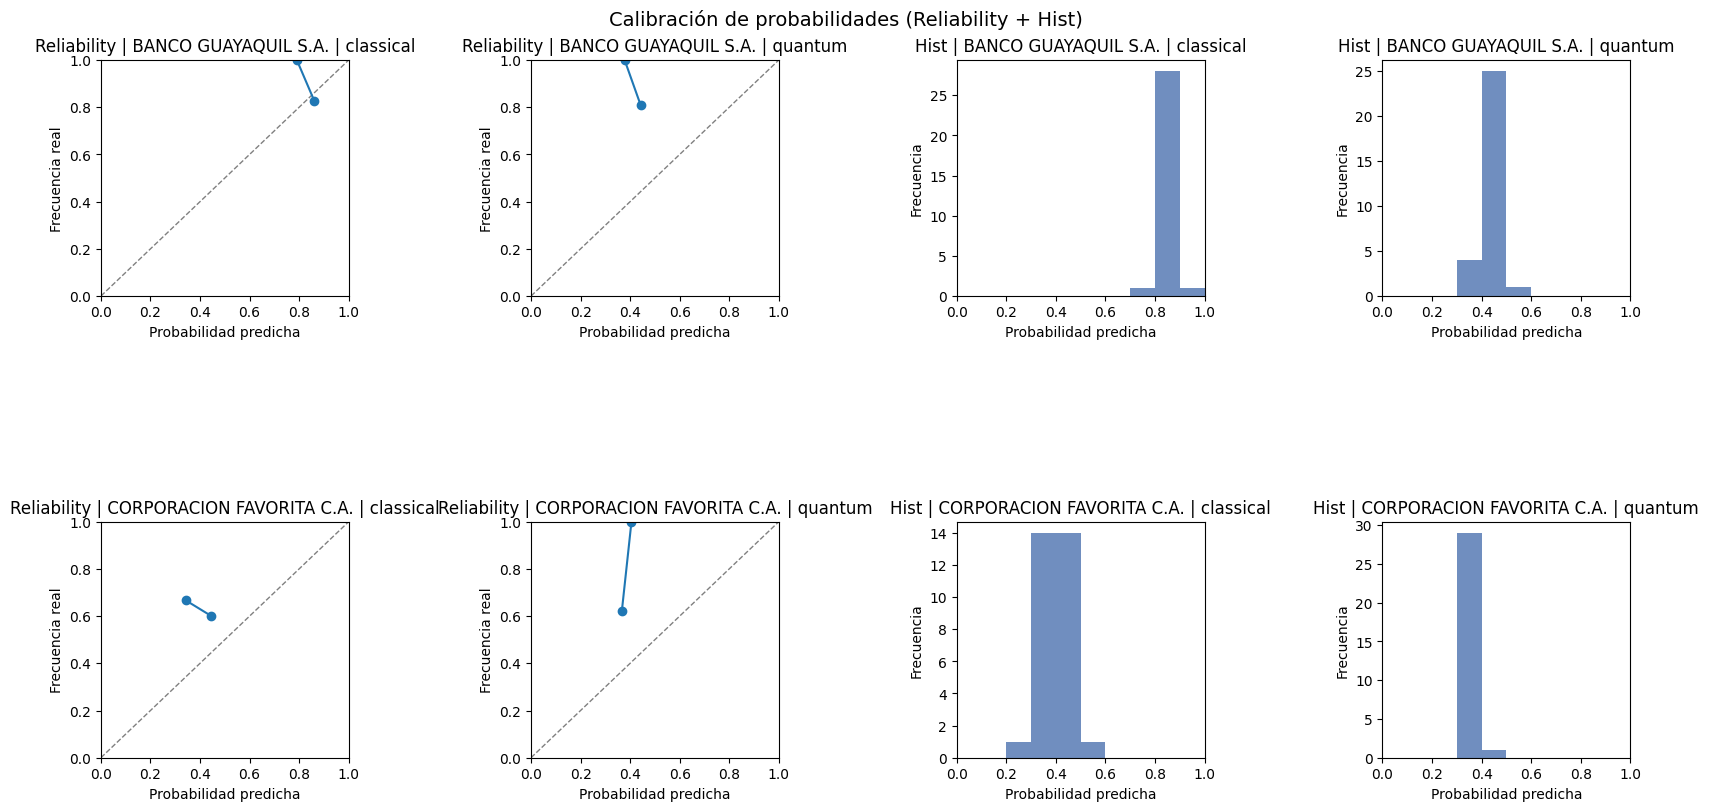

In [6]:
fig = plt.figure(figsize=(16, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=4, wspace=0.3, hspace=0.4)

for i, company in enumerate(COMPANIES):
    for j, model_family in enumerate(MODEL_FAMILIES):
        ax_rel = fig.add_subplot(gs[i, j])
        payload = results[(company, model_family)]
        ax_rel.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
        ax_rel.plot(payload['prob_pred'], payload['prob_true'], marker='o')
        ax_rel.set_title(f'Reliability | {company} | {model_family}')
        ax_rel.set_xlabel('Probabilidad predicha')
        ax_rel.set_ylabel('Frecuencia real')
        ax_rel.set_xlim(0, 1)
        ax_rel.set_ylim(0, 1)

        ax_hist = fig.add_subplot(gs[i, j + 2])
        ax_hist.hist(payload['proba'], bins=10, range=(0, 1), color='#4C72B0', alpha=0.8)
        ax_hist.set_title(f'Hist | {company} | {model_family}')
        ax_hist.set_xlabel('Probabilidad predicha')
        ax_hist.set_ylabel('Frecuencia')
        ax_hist.set_xlim(0, 1)

fig.suptitle('Calibración de probabilidades (Reliability + Hist)', fontsize=14)
fig.savefig(OUT_PNG, dpi=150)
OUT_PNG

In [7]:
if not OUT_CSV.exists():
    raise FileNotFoundError(f'CSV no encontrado: {OUT_CSV}')
if not OUT_PNG.exists():
    raise FileNotFoundError(f'PNG no encontrado: {OUT_PNG}')

print('Archivos generados correctamente:')
print(f'- {OUT_CSV.as_posix()}')
print(f'- {OUT_PNG.as_posix()}')
display(metrics_df)

Archivos generados correctamente:
- C:/Users/leynd/Desktop/Tesis/implementaciones/desarrollov3/results/fase4_comparativa/BVG_subfase8b_calibracion.csv
- C:/Users/leynd/Desktop/Tesis/implementaciones/desarrollov3/results/fase4_comparativa/BVG_calibracion_plot.png


,company,model_family,ece,mean_proba,std_proba,pct_proba_above_60,pct_proba_below_40
0,BANCO GUAYAQUIL S.A.,classical,0.039081,0.858456,0.026948,100.0,0.000000
1,BANCO GUAYAQUIL S.A.,quantum,0.399190,0.434143,0.032684,0.0,13.333333
2,CORPORACION FAVORITA C.A.,classical,0.239161,0.394172,0.057934,0.0,50.000000
3,CORPORACION FAVORITA C.A.,quantum,0.265538,0.367795,0.015530,0.0,96.666667


## Bloque 2: Contraste estadístico
Se reconstruyen predicciones de prueba y se aplica McNemar con intervalos de confianza para accuracy.

In [8]:
FASE4_RESULTS.mkdir(parents=True, exist_ok=True)

OUT_STATS_FILE = FASE4_RESULTS / 'BVG_subfase8_test_estadistico.csv'
OUT_CONTINGENCY_FILE = FASE4_RESULTS / 'BVG_subfase8_tablas_contingencia.csv'

REQUIRED_MANIFEST_FIELDS = [
    'company',
    'model_family',
    'feature_columns',
    'target_column',
    'train_end_date',
]

In [9]:
classical_paths = sorted(CLASSICAL_DIR.glob('*_manifest.json'))
quantum_paths = sorted(QUANTUM_DIR.glob('*_manifest.json'))
expected_paths = classical_paths + quantum_paths

if not expected_paths:
    raise FileNotFoundError(
        f'No se encontraron manifests. Se esperaban archivos *_manifest.json en:'
        f'- {CLASSICAL_DIR.as_posix()}'
        f'- {QUANTUM_DIR.as_posix()}'
    )

manifests = []
for path in expected_paths:
    payload = load_manifest(path, required_fields=REQUIRED_MANIFEST_FIELDS)
    if not isinstance(payload.get('feature_columns'), list):
        raise ValueError(f'Manifest {path.name} tiene feature_columns inválido (se esperaba list).')
    manifests.append(payload)
if not manifests:
    raise ValueError('No se encontraron manifests para procesar.')
classical_manifests = [m for m in manifests if m.get('model_family') == 'classical']
quantum_manifests = [m for m in manifests if m.get('model_family') == 'quantum']

if not classical_manifests:
    raise ValueError('No se encontraron manifests clásicos para procesar.')
if not quantum_manifests:
    raise ValueError('No se encontraron manifests cuánticos para procesar.')


In [10]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Dataset no encontrado: {DATASET_PATH}')

df = pd.read_csv(DATASET_PATH)

required_cols = {FECHA_COL_2, EMPRESA_COL, TARGET_COL}
missing_cols = sorted(required_cols.difference(df.columns))
if missing_cols:
    raise ValueError(f'Columnas faltantes en dataset: {missing_cols}')

df = df.assign(**{FECHA_COL_2: pd.to_datetime(df[FECHA_COL_2], errors='coerce')})
if df[FECHA_COL_2].isna().any():
    raise ValueError('Hay fechas inválidas en columna fecha.')


In [11]:
feature_cols_by_company = {}
target_col_by_company = {}

for payload in manifests:
    company = payload['company']
    feature_cols = payload['feature_columns']
    target_col = payload.get('target_column', TARGET_COL)

    missing = [col for col in feature_cols + [target_col] if col not in df.columns]
    if missing:
        raise ValueError(
            f'Columnas faltantes en dataset para {company}: {missing}'
        )

    feature_cols_by_company[company] = feature_cols
    target_col_by_company[company] = target_col


In [12]:
splits_by_company = {}
clean_df_by_company = {}

for company in sorted(feature_cols_by_company.keys()):
    feature_cols = feature_cols_by_company[company]
    target_col = target_col_by_company[company]

    df_company = df.loc[df[EMPRESA_COL] == company]
    df_company_clean = df_company.dropna(subset=[target_col])
    clean_df_by_company[company] = df_company_clean

    tr, te, X_train, y_train, X_test, y_test = temporal_split_company(
        df_company_clean,
        company,
        test_size=TEST_SIZE,
        company_col=EMPRESA_COL,
        date_col=FECHA_COL_2,
        target_col=target_col,
        feature_cols=feature_cols,
    )

    splits_by_company[company] = {
        'train_df': tr,
        'test_df': te,
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
    }


In [13]:
classical_artifacts = {}

for payload in classical_manifests:
    company = payload['company']
    tag = safe_company(company)
    pipeline_path = CLASSICAL_DIR / f'{tag}_h5_pipeline.joblib'
    if not pipeline_path.exists():
        raise FileNotFoundError(f'Pipeline clásico no encontrado: {pipeline_path}')

    classical_artifacts[company] = {
        'manifest': payload,
        'pipeline': joblib.load(pipeline_path),
        'pipeline_path': pipeline_path,
    }


In [14]:
quantum_artifacts = {}

for payload in quantum_manifests:
    company = payload['company']
    tag = safe_company(company)

    scaler_path = QUANTUM_DIR / f'{tag}_h5_scaler.joblib'
    pca_path = QUANTUM_DIR / f'{tag}_h5_pca.joblib'
    svc_path = QUANTUM_DIR / f'{tag}_h5_svc.joblib'
    kernel_config_path = QUANTUM_DIR / f'{tag}_h5_kernel_config.json'

    for path in [scaler_path, pca_path, svc_path, kernel_config_path]:
        if not path.exists():
            raise FileNotFoundError(f'Artifacto cuántico no encontrado: {path}')

    kernel_config = json.loads(kernel_config_path.read_text(encoding='utf-8'))
    qkernel = build_qkernel(kernel_config)

    feature_cols = feature_cols_by_company[company]
    train_end_date = payload.get('train_end_date')
    df_company_clean = clean_df_by_company.get(company)
    if df_company_clean is None:
        df_company = df.loc[df[EMPRESA_COL] == company]
        df_company_clean = df_company.dropna(subset=[target_col_by_company[company]])

    scaler = joblib.load(scaler_path)
    pca = joblib.load(pca_path)
    svc = joblib.load(svc_path)

    # Usar el mismo train_df del split temporal para garantizar paridad
    tr = splits_by_company[company]['train_df']
    X_train_raw = tr.loc[:, feature_cols].copy()
    if X_train_raw.isna().any().any():
        raise ValueError(f"X_train tiene NaN para {company}")
    X_train_q = pca.transform(scaler.transform(X_train_raw))

    quantum_artifacts[company] = {
        'manifest': payload,
        'scaler': scaler,
        'pca': pca,
        'svc': svc,
        'kernel_config': kernel_config,
        'qkernel': qkernel,
        'X_train_q': X_train_q,
        'artifact_paths': {
            'scaler': scaler_path,
            'pca': pca_path,
            'svc': svc_path,
            'kernel_config': kernel_config_path,
        },
    }


In [15]:
def _get_proba(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return np.full((X.shape[0],), np.nan)

def compute_contingency(y_true, y_pred_classical, y_pred_quantum):
    correct_classical = y_pred_classical == y_true
    correct_quantum = y_pred_quantum == y_true
    both_correct = int(np.sum(correct_classical & correct_quantum))
    classical_only = int(np.sum(correct_classical & ~correct_quantum))
    quantum_only = int(np.sum(~correct_classical & correct_quantum))
    both_wrong = int(np.sum(~correct_classical & ~correct_quantum))
    return both_correct, classical_only, quantum_only, both_wrong

def compute_mcnemar(b, c):
    use_correction = (b + c) < 25
    result = mcnemar([[0, b], [c, 0]], exact=False, correction=use_correction)
    return float(result.statistic), float(result.pvalue), use_correction

def compute_accuracy_ci(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    lower, upper = proportion_confint(
        count=int(np.sum(y_true == y_pred)),
        nobs=len(y_true),
        alpha=0.05,
        method='wilson',
    )
    return float(acc), float(lower), float(upper)


In [16]:
prediction_rows = []
stats_rows = []
contingency_rows = []

for company in sorted(splits_by_company.keys()):
    split = splits_by_company[company]
    X_test = split['X_test']
    y_test = split['y_test']
    test_df = split['test_df'].copy()

    if X_test.isna().any().any():
        raise ValueError(f'NaN detectado en X_test para {company}.')

    classical_bundle = classical_artifacts.get(company)
    quantum_bundle = quantum_artifacts.get(company)
    if not classical_bundle or not quantum_bundle:
        raise ValueError(f'Faltan artefactos para {company}.')

    pipeline = classical_bundle['pipeline']
    y_pred_classical = pipeline.predict(X_test)
    proba_classical = _get_proba(pipeline, X_test)

    scaler = quantum_bundle['scaler']
    pca = quantum_bundle['pca']
    svc = quantum_bundle['svc']
    qkernel = quantum_bundle['qkernel']
    X_train_q = quantum_bundle['X_train_q']
    X_test_q = pca.transform(scaler.transform(X_test))
    K_test = qkernel.evaluate(x_vec=X_test_q, y_vec=X_train_q)
    y_pred_quantum = svc.predict(K_test)
    proba_quantum = _get_proba(svc, K_test)

    for idx in range(len(test_df)):
        prediction_rows.append({
            'company': company,
            'fecha': test_df.iloc[idx][FECHA_COL_2],
            'y_test': int(y_test.iloc[idx]),
            'y_pred_classical': int(y_pred_classical[idx]),
            'y_pred_quantum': int(y_pred_quantum[idx]),
            'proba_classical': float(proba_classical[idx]) if not np.isnan(proba_classical[idx]) else np.nan,
            'proba_quantum': float(proba_quantum[idx]) if not np.isnan(proba_quantum[idx]) else np.nan,
        })

    both_correct, classical_only, quantum_only, both_wrong = compute_contingency(
        y_test.to_numpy(),
        y_pred_classical,
        y_pred_quantum,
    )
    mcnemar_stat, mcnemar_pvalue, used_correction = compute_mcnemar(classical_only, quantum_only)

    acc, acc_low, acc_up = compute_accuracy_ci(y_test.to_numpy(), y_pred_classical)
    f1 = f1_score(y_test.to_numpy(), y_pred_classical, zero_division=0)

    stats_rows.append({
        'company': company,
        'model_family': 'classical',
        'n_test': int(len(y_test)),
        'accuracy': acc,
        'acc_ci_lower': acc_low,
        'acc_ci_upper': acc_up,
        'f1': float(f1),
        'mcnemar_chi2': mcnemar_stat,
        'mcnemar_pvalue': mcnemar_pvalue,
        'mcnemar_significativo': bool(mcnemar_pvalue < 0.05),
        'mcnemar_conclusion': 'Diferencia significativa' if mcnemar_pvalue < 0.05 else 'No significativa',
    })

    acc_q, acc_q_low, acc_q_up = compute_accuracy_ci(y_test.to_numpy(), y_pred_quantum)
    f1_q = f1_score(y_test.to_numpy(), y_pred_quantum, zero_division=0)

    stats_rows.append({
        'company': company,
        'model_family': 'quantum',
        'n_test': int(len(y_test)),
        'accuracy': acc_q,
        'acc_ci_lower': acc_q_low,
        'acc_ci_upper': acc_q_up,
        'f1': float(f1_q),
        'mcnemar_chi2': mcnemar_stat,
        'mcnemar_pvalue': mcnemar_pvalue,
        'mcnemar_significativo': bool(mcnemar_pvalue < 0.05),
        'mcnemar_conclusion': 'Diferencia significativa' if mcnemar_pvalue < 0.05 else 'No significativa',
    })

    contingency_rows.append({
        'company': company,
        'both_correct': both_correct,
        'classical_only': classical_only,
        'quantum_only': quantum_only,
        'both_wrong': both_wrong,
    })

    if used_correction:
        print(f'McNemar: Edwards correction aplicada para {company} (b+c < 25).')

pred_df = pd.DataFrame(prediction_rows)
stats_df = pd.DataFrame(stats_rows)
contingency_df = pd.DataFrame(contingency_rows)

if pred_df.empty:
    raise ValueError('No se generaron predicciones para exportar.')
if stats_df.empty:
    raise ValueError('No se generaron estadísticas para exportar.')
if contingency_df.empty:
    raise ValueError('No se generaron tablas de contingencia para exportar.')

stats_df = stats_df.sort_values(['company', 'model_family']).reset_index(drop=True)
contingency_df = contingency_df.sort_values(['company']).reset_index(drop=True)

stats_df.to_csv(OUT_STATS_FILE, index=False)
contingency_df.to_csv(OUT_CONTINGENCY_FILE, index=False)

print(f'CSV estadístico exportado en: {OUT_STATS_FILE.as_posix()}')
print(f'CSV contingencia exportado en: {OUT_CONTINGENCY_FILE.as_posix()}')


McNemar: Edwards correction aplicada para BANCO GUAYAQUIL S.A. (b+c < 25).
McNemar: Edwards correction aplicada para CORPORACION FAVORITA C.A. (b+c < 25).
CSV estadístico exportado en: C:/Users/leynd/Desktop/Tesis/implementaciones/desarrollov3/results/fase4_comparativa/BVG_subfase8_test_estadistico.csv
CSV contingencia exportado en: C:/Users/leynd/Desktop/Tesis/implementaciones/desarrollov3/results/fase4_comparativa/BVG_subfase8_tablas_contingencia.csv


## Bloque 3: Evaluación comparativa
Se consolidan métricas finales desde manifiestos para comparar SVC clásico y QSVC en h=5.

In [17]:
OUT_FILE = FASE4_RESULTS / 'BVG_subfase8_comparativa_h5.csv'

MANIFEST_FIELDS = ['company', 'model_family', 'metrics']
METRICS_FIELDS = ['accuracy', 'f1']

def build_comparison_df(manifests: list[dict]) -> pd.DataFrame:
    rows = []
    for payload in manifests:
        metrics = payload.get('metrics', {})
        model_name = payload.get('model_name')
        if not model_name:
            model_name = payload['__manifest_path__'].stem.replace('_manifest', '')
        horizonte = payload.get('horizon') or payload.get('horizonte', 'h5')
        row = {
            'company': payload.get('company'),
            'model_family': payload.get('model_family'),
            'model_name': model_name,
            'horizonte': horizonte,
            'accuracy': metrics.get('accuracy'),
            'f1': metrics.get('f1'),
        }
        for optional_key in ['train_end_date', 'created_at_utc']:
            if optional_key in payload:
                row[optional_key] = payload.get(optional_key)
        rows.append(row)

    df = pd.DataFrame(rows)
    required_cols = ['company', 'model_family', 'model_name', 'horizonte', 'accuracy', 'f1']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f'Columnas requeridas ausentes en DataFrame: {missing_cols}')

    df = df.sort_values(['company', 'model_family', 'model_name']).reset_index(drop=True).copy()
    return df

def export_comparison(df: pd.DataFrame, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)

classical_manifests = sorted(CLASSICAL_DIR.glob('*_manifest.json'))
quantum_manifests = sorted(QUANTUM_DIR.glob('*_manifest.json'))
expected_paths = classical_manifests + quantum_manifests

if not expected_paths:
    raise FileNotFoundError(
        'No se encontraron manifests. Se esperaban archivos *_manifest.json en:'
        f'{CLASSICAL_DIR.as_posix()}\n- {QUANTUM_DIR.as_posix()}'
    )

manifests = []
for path in expected_paths:
    payload = load_manifest(path, required_fields=MANIFEST_FIELDS)
    if not isinstance(payload.get('metrics'), dict):
        raise ValueError(f'Manifest {path.name} tiene metrics inválido (se esperaba dict).')
    payload['__manifest_path__'] = path
    manifests.append(payload)
if not manifests:
    raise ValueError('No se encontraron manifests para procesar.')
comparison_df = build_comparison_df(manifests)

print('Preview comparativo:')
display(comparison_df.head())

export_comparison(comparison_df, OUT_FILE)
print(f'CSV exportado en: {OUT_FILE.as_posix()}')

Preview comparativo:


,company,model_family,model_name,horizonte,accuracy,f1,train_end_date,created_at_utc
0,BANCO GUAYAQUIL S.A.,classical,BANCO_GUAYAQUIL_SA_h5,h5,0.833333,0.909091,2026-01-21,2026-04-27T17:02:54.735305+00:00
1,BANCO GUAYAQUIL S.A.,quantum,BANCO_GUAYAQUIL_SA_h5,h5,0.366667,0.457143,2026-01-21,2026-04-27T18:12:46.804042+00:00
2,CORPORACION FAVORITA C.A.,classical,CORPORACION_FAVORITA_CA_h5,h5,0.433333,0.514286,2026-01-28,2026-04-27T17:02:55.358077+00:00
3,CORPORACION FAVORITA C.A.,quantum,CORPORACION_FAVORITA_CA_h5,h5,0.400000,0.307692,2026-01-28,2026-04-27T20:49:06.652582+00:00


CSV exportado en: C:/Users/leynd/Desktop/Tesis/implementaciones/desarrollov3/results/fase4_comparativa/BVG_subfase8_comparativa_h5.csv


## Resultado de subfase
- Se exportaron resultados de calibración, contraste estadístico, tablas de contingencia y comparación final en `results/fase4_comparativa/`.
- En h=5, el modelo clásico superó al cuántico en accuracy y F1 para ambos emisores según `BVG_subfase8_comparativa_h5.csv`.
- La prueba de McNemar fue significativa para Banco Guayaquil y no significativa para Corporación Favorita según `BVG_subfase8_test_estadistico.csv`.